In [1]:
import json
import pandas as pd

# 检查 match_meta.json 里是否有球员和助攻字段
with open('../data/raw/match_meta.json', 'r') as f:
    meta_data = json.load(f)

print(f"总比赛条数: {len(meta_data)}")
sample_match = meta_data[0] if isinstance(meta_data, list) else list(meta_data.values())[0]
print("单场元数据包含的键:", list(sample_match.keys()) if isinstance(sample_match, dict) else type(sample_match))

总比赛条数: 104
单场元数据包含的键: ['IdMatch', 'IdStage', 'IdGroup', 'IdSeason', 'CoverageLevel', 'IdCompetition', 'CompetitionName', 'SeasonName', 'SeasonShortName', 'Stadium', 'ResultType', 'MatchDay', 'MatchNumber', 'HomeTeamPenaltyScore', 'AwayTeamPenaltyScore', 'AggregateHomeTeamScore', 'AggregateAwayTeamScore', 'Weather', 'Attendance', 'Date', 'LocalDate', 'MatchTime', 'SecondHalfTime', 'FirstHalfTime', 'FirstHalfExtraTime', 'SecondHalfExtraTime', 'Winner', 'Period', 'HomeTeam', 'AwayTeam', 'BallPossession', 'TerritorialPossesion', 'TerritorialThirdPossesion', 'Officials', 'MatchStatus', 'GroupName', 'StageName', 'OfficialityStatus', 'TimeDefined', 'Properties', 'IsUpdateable']


In [2]:
home_team = sample_match.get('HomeTeam', {})
print("Type of HomeTeam:", type(home_team))
if isinstance(home_team, dict):
    print("Keys in HomeTeam:", list(home_team.keys()))
    for k in ['Players', 'Squad', 'Lineup', 'Substitutes', 'Tactics']:
        if k in home_team:
            print(f"Found key '{k}' with {len(home_team[k])} items")
            if len(home_team[k]) > 0:
                print(f"Sample from '{k}':", home_team[k][0])

Type of HomeTeam: <class 'dict'>
Keys in HomeTeam: ['Score', 'Side', 'IdTeam', 'PictureUrl', 'IdCountry', 'TeamType', 'AgeType', 'Tactics', 'TeamName', 'Abbreviation', 'Coaches', 'Players', 'Bookings', 'Goals', 'Substitutions', 'Staffs', 'FootballType', 'Gender', 'IdAssociation', 'ShortClubName']
Found key 'Players' with 25 items
Sample from 'Players': {'IdPlayer': '484012', 'IdTeam': '43995', 'ShirtNumber': 1, 'Status': 1, 'SpecialStatus': None, 'Captain': False, 'PlayerName': [{'Locale': 'en-GB', 'Description': 'Matej KOVAR'}], 'ShortName': [{'Locale': 'en-GB', 'Description': 'Matej KOVAR'}], 'Position': 0, 'PlayerPicture': {'Id': '06F2BDBF-6411-4F1C-885B3C745E37363E', 'PictureUrl': 'https://digitalhub.fifa.com/transform/06f2bdbf-6411-4f1c-885b-3c745e37363e/KOVAR-Matej_484012'}, 'FieldStatus': 0, 'LineupX': None, 'LineupY': None}
Found key 'Tactics' with 5 items
Sample from 'Tactics': 3


In [3]:
import os

print("Files in ../src:")
if os.path.exists('../src'):
    print(os.listdir('../src'))

print("\nFiles in ../data:")
for root, dirs, files in os.walk('../data'):
    for file in files:
        if not file.startswith('.'):
            print(os.path.join(root, file))

Files in ../src:
['fetch_metadata.py', 'config.py', 'scrape_match_stats.py', 'build_dataset.py']

Files in ../data:
../data/clean/team_match.csv
../data/clean/match_meta.csv
../data/raw/match_meta.json
../data/raw/pages/400021465.txt
../data/raw/pages/400021471.txt
../data/raw/pages/400021459.txt
../data/raw/pages/400021511.txt
../data/raw/pages/400021505.txt
../data/raw/pages/400021539.txt
../data/raw/pages/400021538.txt
../data/raw/pages/400021504.txt
../data/raw/pages/400021510.txt
../data/raw/pages/400021458.txt
../data/raw/pages/400021470.txt
../data/raw/pages/400021464.txt
../data/raw/pages/400021499.txt
../data/raw/pages/400021472.txt
../data/raw/pages/400021466.txt
../data/raw/pages/400021506.txt
../data/raw/pages/400021512.txt
../data/raw/pages/400021513.txt
../data/raw/pages/400021507.txt
../data/raw/pages/400021467.txt
../data/raw/pages/400021473.txt
../data/raw/pages/400021498.txt
../data/raw/pages/400021488.txt
../data/raw/pages/400021477.txt
../data/raw/pages/400021463.tx

In [4]:
import requests
import json

# Check the official FIFA tournament statistics API endpoints for players
candidate_urls = [
    "https://api.fifa.com/api/v3/statistics/player-statistics",
    "https://api.fifa.com/api/v3/statistics/players",
    "https://api.fifa.com/api/v3/tournaments/statistics/players",
    "https://api.fifa.com/api/v3/live/football/players"
]

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

for url in candidate_urls:
    try:
        resp = requests.get(url, headers=headers, timeout=5)
        print(f"URL: {url} -> Status: {resp.status_code}")
    except Exception as e:
        print(f"URL: {url} -> Error: {type(e).__name__}")

URL: https://api.fifa.com/api/v3/statistics/player-statistics -> Status: 404
URL: https://api.fifa.com/api/v3/statistics/players -> Status: 404
URL: https://api.fifa.com/api/v3/tournaments/statistics/players -> Status: 404
URL: https://api.fifa.com/api/v3/live/football/players -> Status: 200


In [5]:
resp = requests.get("https://api.fifa.com/api/v3/live/football/players", headers=headers, timeout=10)
data = resp.json()

print("Data type:", type(data))
if isinstance(data, dict):
    print("Keys:", list(data.keys()))
    sample_key = list(data.keys())[0]
    print(f"Sample under '{sample_key}':", type(data[sample_key]))
    if isinstance(data[sample_key], list) and len(data[sample_key]) > 0:
        print("Sample item:", data[sample_key][0])
elif isinstance(data, list) and len(data) > 0:
    print("Total items:", len(data))
    print("Sample item keys:", list(data[0].keys()) if isinstance(data[0], dict) else data[0])

Data type: <class 'NoneType'>


In [6]:
with open('../src/config.py', 'r') as f:
    print("--- config.py ---")
    print(f.read()[:1000])

with open('../src/build_dataset.py', 'r') as f:
    print("\n--- build_dataset.py ---")
    print(f.read()[:1000])

--- config.py ---
"""Shared configuration for the HIT140 Assessment 2 data pipeline.

Match index verified against the FIFA fixtures page on 2026-08-16:
all 104 match IDs are consecutive from 400021440 to 400021543, and the
stage boundaries fall exactly where the tournament structure says they should.
That means we do not need to scrape the fixtures page at all.
"""

from pathlib import Path

# ---------------------------------------------------------------- paths

ROOT = Path(__file__).resolve().parent.parent
RAW = ROOT / "data" / "raw"
CLEAN = ROOT / "data" / "clean"
FIGURES = ROOT / "figures"

for _d in (RAW, CLEAN, FIGURES):
    _d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------- tournament

COMPETITION_ID = 17
SEASON_ID = 285023

# stage_id -> (human readable name, is_group_stage, first_match_id, last_match_id)
STAGES = {
    289273: ("Group stage", True, 400021440, 400021511),   # 72 matches
    289287: ("Round of 32", False, 

In [7]:
import requests
import pandas as pd

comp_id = 17
season_id = 285023

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

test_urls = [
    f"https://api.fifa.com/api/v3/statistics/players?idCompetition={comp_id}&idSeason={season_id}",
    f"https://api.fifa.com/api/v3/tournaments/17/seasons/285023/players",
    f"https://api.fifa.com/api/v3/live/football/17/285023/stats/players",
    f"https://api.fifa.com/api/v3/calendar/17/285023/players"
]

for url in test_urls:
    try:
        r = requests.get(url, headers=headers, timeout=6)
        print(f"Status: {r.status_code} | URL: {url}")
        if r.status_code == 200:
            sample_json = r.json()
            print("Response type:", type(sample_json))
            if isinstance(sample_json, dict):
                print("Keys:", list(sample_json.keys())[:10])
            elif isinstance(sample_json, list) and len(sample_json) > 0:
                print("First element keys:", list(sample_json[0].keys())[:10])
            break
    except Exception as e:
        print("Error:", type(e).__name__)

Status: 404 | URL: https://api.fifa.com/api/v3/statistics/players?idCompetition=17&idSeason=285023
Status: 404 | URL: https://api.fifa.com/api/v3/tournaments/17/seasons/285023/players
Status: 200 | URL: https://api.fifa.com/api/v3/live/football/17/285023/stats/players
Response type: <class 'NoneType'>


In [8]:
with open('../src/scrape_match_stats.py', 'r') as f:
    print(f.read()[:1500])

"""Step 2 — scrape per-match team statistics from the FIFA match pages.

Why a browser is needed: possession, fouls, passes and the rest are rendered
client-side. They are not in the page source and there is no public JSON
endpoint for them (checked: /api/v3/live/... returns BallPossession = null,
/api/v3/statistics/... is a 404, and the CloudFront path only serves
status.json). So we drive a real browser and read the DOM after it renders.

Two things this script has to work around, both found the hard way:

1. **The bot-detection script crashes headless Chromium.** fifa.com serves an
   Akamai sensor script from an obfuscated same-origin path with no file
   extension. With a CDP client attached it kills the browser process with
   SIGTRAP before the page finishes loading. Aborting that one request fixes
   it, and the statistics still render because they come from elsewhere.

2. **The stats mount lazily on scroll**, so the page has to be scrolled to the
   bottom before the text is r

In [9]:
from pathlib import Path

pages_dir = Path('../data/raw/pages')
txt_files = sorted(list(pages_dir.glob('*.txt')))
print(f"Total txt page files: {len(txt_files)}")

if len(txt_files) > 0:
    sample_file = txt_files[0]
    print(f"Reading sample: {sample_file.name}")
    with open(sample_file, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    print(f"Total lines in sample: {len(lines)}")
    print("\n--- First 40 lines ---")
    print("".join(lines[:40]))
    
    # Check if player keywords exist
    text_content = "".join(lines)
    keywords = ['Midfielder', 'Forward', 'Defender', 'Goalkeeper', 'Lineup', 'Substitutions', 'Assists', 'Minutes']
    print("\nKeyword search:")
    for kw in keywords:
        print(f"'{kw}' in page: {kw.lower() in text_content.lower()}")

Total txt page files: 104
Reading sample: 400021440.txt
Total lines in sample: 344

--- First 40 lines ---
Skip to main content
FIFA REWARDS
FIFA+
FIFA STORE
FIFA COLLECT
|
English
|

FIFA WORLD CUP 2026™

FINAL
MATCHES
STANDINGS
TEAMS & STATS
LATEST
FANTASY & GAMING
MORE
Czechia vs. South Africa

Group A • Match 25

01 : 30  •  19 JUN 2026

Czechia
1   -   1
South Africa

Full Time

, Match details, Czechia 1, South Africa 1,
Michal SADILEK
6'
Teboho MOKOENA
83'
(P)
FIFA World Cup 2026™
Atlanta ●Atlanta Stadium
Where to watch



Keyword search:
'Midfielder' in page: False
'Forward' in page: False
'Defender' in page: False
'Goalkeeper' in page: False
'Lineup' in page: False
'Substitutions' in page: False
'Assists' in page: True
'Minutes' in page: False


In [10]:
import os
from pathlib import Path

# Search for any player or golden boot text/csv files across the repository
root_dir = Path('..')
found_files = []
for p in root_dir.glob('**/*'):
    if p.is_file() and any(k in p.name.lower() for k in ['player', 'boot', 'golden', 'scorer', 'gk']):
        found_files.append(str(p))

print("Found player-related files:")
if found_files:
    for f in found_files:
        print(" -", f)
else:
    print("None found.")

# Also check git status to see if any untracked or modified files exist
import subprocess
git_status = subprocess.run(['git', 'status'], capture_output=True, text=True)
print("\nGit Status:")
print(git_status.stdout[:500])

Found player-related files:
None found.

Git Status:
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	task_assists_luke.ipynb

nothing added to commit but untracked files present (use "git add" to track)



In [11]:
import requests
import json
import pandas as pd

# FIFA tournament player statistics public JSON API
api_url = "https://api.fifa.com/api/v3/calendar/17/285023/stat/players"
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
}

resp = requests.get(api_url, headers=headers, timeout=10)
print(f"Status code: {resp.status_code}")

if resp.status_code == 200:
    try:
        data = resp.json()
        print("Data loaded successfully!")
        print("Type:", type(data))
        if isinstance(data, list):
            print(f"Total players: {len(data)}")
            print("First player keys:", list(data[0].keys()))
            df_test = pd.json_normalize(data)
            print("Columns:", df_test.columns.tolist()[:15])
        elif isinstance(data, dict):
            print("Keys:", list(data.keys()))
    except Exception as e:
        print("JSON parse error:", e)
else:
    print("Response text preview:", resp.text[:300])

Status code: 404
Response text preview: The resource you are looking for has been removed, had its name changed, or is temporarily unavailable.


In [12]:
with open('../src/scrape_match_stats.py', 'r') as f:
    code = f.read()

# Find any FIFA URLs inside scrape_match_stats.py
import re
urls = re.findall(r'https?://[^\s"\']+', code)
print("URLs found in scrape_match_stats.py:")
for u in set(urls):
    print(" -", u)

# Check the main scraping logic
print("\n--- Code snippet from scrape_match_stats.py ---")
lines = code.split('\n')
for i, line in enumerate(lines[:60]):
    print(f"{i+1:02d}: {line}")

URLs found in scrape_match_stats.py:
 - https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$

--- Code snippet from scrape_match_stats.py ---
01: """Step 2 — scrape per-match team statistics from the FIFA match pages.
02: 
03: Why a browser is needed: possession, fouls, passes and the rest are rendered
04: client-side. They are not in the page source and there is no public JSON
05: endpoint for them (checked: /api/v3/live/... returns BallPossession = null,
06: /api/v3/statistics/... is a 404, and the CloudFront path only serves
07: status.json). So we drive a real browser and read the DOM after it renders.
08: 
09: Two things this script has to work around, both found the hard way:
10: 
11: 1. **The bot-detection script crashes headless Chromium.** fifa.com serves an
12:    Akamai sensor script from an obfuscated same-origin path with no file
13:    extension. With a CDP client attached it kills the browser process with
14:    SIGTRAP before the page finishe

In [13]:
import sys
sys.path.insert(0, '../src')
import config

print("page_url function source:")
import inspect
print(inspect.getsource(config.page_url))

for k in ['USER_AGENT', 'PAGE_DELAY']:
    if hasattr(config, k):
        print(f"{k}:", getattr(config, k))

page_url function source:
def page_url(stage_id: int, match_id: int) -> str:
    return PAGE_MATCH.format(
        comp=COMPETITION_ID, season=SEASON_ID, stage=stage_id, match_id=match_id
    )

USER_AGENT: Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36 (CDU HIT140 student project; contact via unit coordinator)
PAGE_DELAY: 3.0


In [14]:
import inspect

# Inspect all URL templates and string constants in config.py
print("PAGE_MATCH template:")
if hasattr(config, 'PAGE_MATCH'):
    print(getattr(config, 'PAGE_MATCH'))

print("\nAll variables and constants in config:")
for attr in dir(config):
    if not attr.startswith('__'):
        val = getattr(config, attr)
        if isinstance(val, (str, int, float, dict, list)):
            print(f"{attr}: {repr(val)[:120]}")

PAGE_MATCH template:
https://www.fifa.com/en/match-centre/match/{comp}/{season}/{stage}/{match_id}

All variables and constants in config:
API_MATCH: 'https://api.fifa.com/api/v3/live/football/{match_id}?language=en'
COMPETITION_ID: 17
MATCH_INDEX: [(289273, 'Group stage', True, 400021440), (289273, 'Group stage', True, 400021441), (289273, 'Group stage', True, 40002
PAGE_DELAY: 3.0
PAGE_MATCH: 'https://www.fifa.com/en/match-centre/match/{comp}/{season}/{stage}/{match_id}'
REQUEST_DELAY: 2.0
SEASON_ID: 285023
STAGES: {289273: ('Group stage', True, 400021440, 400021511), 289287: ('Round of 32', False, 400021512, 400021527), 289288: ('Ro
USER_AGENT: 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36 (CDU 


In [15]:
goals_sample = sample_match.get('HomeTeam', {}).get('Goals', [])
subs_sample = sample_match.get('HomeTeam', {}).get('Substitutions', [])

print("Sample match Goals list length:", len(goals_sample))
if len(goals_sample) > 0:
    print("Goal event structure:", goals_sample[0])

print("Sample match Substitutions list length:", len(subs_sample))
if len(subs_sample) > 0:
    print("Substitution event structure:", subs_sample[0])

Sample match Goals list length: 1
Goal event structure: {'Type': 2, 'IdPlayer': '433668', 'Minute': "6'", 'IdAssistPlayer': None, 'Period': 3, 'IdGoal': None, 'IdTeam': '43995'}
Sample match Substitutions list length: 5
Substitution event structure: {'IdEvent': None, 'Period': 5, 'Reason': 0, 'SubstitutePosition': 2, 'IdPlayerOff': '358003', 'IdPlayerOn': '486082', 'PlayerOffName': [{'Locale': 'en-GB', 'Description': 'Vladimir DARIDA'}], 'PlayerOnName': [{'Locale': 'en-GB', 'Description': 'Pavel SULC'}], 'Minute': "55'", 'IdTeam': '43995'}


In [16]:
total_goals = 0
total_assists = 0

for match in meta_data:
    for side in ['HomeTeam', 'AwayTeam']:
        team_data = match.get(side, {})
        for goal in team_data.get('Goals', []):
            total_goals += 1
            if goal.get('IdAssistPlayer'):
                total_assists += 1

print(f"Total Matches: {len(meta_data)}")
print(f"Total Goals Recorded: {total_goals}")
print(f"Total Assists Recorded: {total_assists}")

Total Matches: 104
Total Goals Recorded: 333
Total Assists Recorded: 0


In [17]:
import time
import re
from playwright.sync_api import sync_playwright

stats_url = "https://www.fifa.com/en/tournaments/mens/worldcup/2026/statistics/player-statistics"

print("Starting browser session...")
with sync_playwright() as p:
    browser = p.chromium.launch(headless=True)
    context = browser.new_context(
        user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    )
    page = context.new_page()
    
    # Abort tracking/sensor requests matching the pattern from scrape_match_stats.py
    page.route(re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$"), lambda r: r.abort())
    
    print(f"Navigating to {stats_url} ...")
    page.goto(stats_url, timeout=60000, wait_until="domcontentloaded")
    time.sleep(5)
    
    # Scroll down and click 'Load more' repeatedly if present
    for i in range(15):
        page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
        time.sleep(2)
        load_more_btn = page.locator("text=/Load more|Show more/i")
        if load_more_btn.count() > 0 and load_more_btn.first.is_visible():
            print(f"Clicking 'Load more' round {i+1}...")
            load_more_btn.first.click()
            time.sleep(2)
        else:
            break
            
    content = page.content()
    inner_text = page.inner_text("body")
    print(f"Page title: {page.title()}")
    print(f"Captured text length: {len(inner_text)}")
    
    with open("../data/raw/player_stats_page.txt", "w", encoding="utf-8") as f:
        f.write(inner_text)
    print("Saved rendered text to ../data/raw/player_stats_page.txt")
    
    browser.close()

ModuleNotFoundError: No module named 'playwright'

In [18]:
import sys
!{sys.executable} -m pip install playwright
!{sys.executable} -m playwright install chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 MB 5.5 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [playwright]3 [playwright]
187.7 MiB [                    ] 0% 0.0s187.7 MiB [                    ] 0% 1405.8s187.7 MiB [                    ] 0% 896.4s187.7 MiB [                    ] 0% 1004.9s187.7 MiB [                    ] 0% 784.1s187.7 MiB [                    ] 0% 1126.0s187.7 MiB [                    ] 0% 956.1s187.7 MiB [                    ] 0% 1064.9s187.7 MiB [                    ] 0% 943.5s187.7 MiB [                    ] 0% 853.4s187.7 MiB [                    ] 0% 790.2s187.7 MiB [                    ] 0% 745.1s187.7 MiB [                    ] 0% 707.8s187.7 MiB [                    ] 0% 672.9s187.7 MiB [                    ] 0% 639.8s187.7 MiB [                    ] 0% 607.1s187.7 MiB [                    ] 0% 580.0s187.7 MiB [                    ] 0% 555.7s187.7 MiB [                    ] 0% 522.0s187.7 MiB [                    ] 0% 5

In [19]:
import time
import re
from playwright.sync_api import sync_playwright

stats_url = "https://www.fifa.com/en/tournaments/mens/worldcup/2026/statistics/player-statistics"

with sync_playwright() as p:
    browser = p.chromium.launch(headless=True)
    context = browser.new_context(
        user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
    )
    page = context.new_page()
    
    sensor_pattern = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
    page.route(sensor_pattern, lambda r: r.abort())
    
    print(f"Loading: {stats_url}")
    page.goto(stats_url, timeout=60000, wait_until="domcontentloaded")
    time.sleep(5)
    
    for i in range(15):
        page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
        time.sleep(2)
        load_more = page.locator("text=/Load more|Show more/i")
        if load_more.count() > 0 and load_more.first.is_visible():
            print(f"Clicking 'Load more' round {i+1}...")
            load_more.first.click()
            time.sleep(2)
        else:
            break
            
    inner_text = page.inner_text("body")
    print(f"Page title: {page.title()}")
    print(f"Text length captured: {len(inner_text)}")
    
    with open("../data/raw/player_stats_page.txt", "w", encoding="utf-8") as f:
        f.write(inner_text)
    print("Saved text to ../data/raw/player_stats_page.txt")
    
    browser.close()

Error: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.

In [20]:
import asyncio
import re
from playwright.async_api import async_playwright

stats_url = "https://www.fifa.com/en/tournaments/mens/worldcup/2026/statistics/player-statistics"

async def scrape_player_page():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
        )
        page = await context.new_page()
        
        sensor_pattern = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pattern, lambda route: route.abort())
        
        print(f"Loading: {stats_url}")
        await page.goto(stats_url, timeout=60000, wait_until="domcontentloaded")
        await asyncio.sleep(5)
        
        for i in range(15):
            await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
            await asyncio.sleep(2)
            load_more = page.locator("text=/Load more|Show more/i")
            if await load_more.count() > 0 and await load_more.first.is_visible():
                print(f"Clicking 'Load more' round {i+1}...")
                await load_more.first.click()
                await asyncio.sleep(2)
            else:
                break
                
        inner_text = await page.inner_text("body")
        print(f"Page title: {await page.title()}")
        print(f"Text length captured: {len(inner_text)}")
        
        with open("../data/raw/player_stats_page.txt", "w", encoding="utf-8") as f:
            f.write(inner_text)
        print("Saved text to ../data/raw/player_stats_page.txt")
        
        await browser.close()

await scrape_player_page()

Loading: https://www.fifa.com/en/tournaments/mens/worldcup/2026/statistics/player-statistics
Page title: 
Text length captured: 559
Saved text to ../data/raw/player_stats_page.txt


In [21]:
with open("../data/raw/player_stats_page.txt", "r", encoding="utf-8") as f:
    preview_text = f.read()

print("--- Captured Content Preview ---")
print(preview_text)

--- Captured Content Preview ---
Skip to main content
FIFA REWARDS
FIFA+
FIFA STORE
FIFA COLLECT
|
English
TOURNAMENTS & EVENTS
MATCHES & STATS
NEWS
RANKINGS
MORE
Come on referee, you weren't supposed to see this!
Your Privacy
We use cookies to personalise content and ads, to provide social media features and to analyse our traffic. We also share information about your use of our site with our social media, advertising and analytics partners. You can select your cookie preferences by clicking the buttons on the right. Data Protection Portal
Preference Center Reject All I'm OK with that


In [22]:
import asyncio
import re
from playwright.async_api import async_playwright

candidate_stats_urls = [
    "https://www.fifa.com/en/match-centre/competition/17/season/285023/statistics",
    "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics",
    "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/players"
]

async def probe_urls():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
        )
        page = await context.new_page()
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        for u in candidate_stats_urls:
            print(f"Trying: {u}")
            try:
                resp = await page.goto(u, timeout=30000, wait_until="domcontentloaded")
                await asyncio.sleep(4)
                text = await page.inner_text("body")
                is_404 = "you weren't supposed to see this" in text.lower()
                print(f" -> Result: {'404 Not Found' if is_404 else 'Valid Page! (Length: ' + str(len(text)) + ')'}")
                if not is_404 and len(text) > 1000:
                    with open("../data/raw/player_stats_page.txt", "w", encoding="utf-8") as f:
                        f.write(text)
                    print(f"Saved successful page from {u}")
                    break
            except Exception as err:
                print(f" -> Error: {type(err).__name__}")
                
        await browser.close()

await probe_urls()

Trying: https://www.fifa.com/en/match-centre/competition/17/season/285023/statistics
 -> Result: Valid Page! (Length: 643)
Trying: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics
 -> Result: Valid Page! (Length: 544)
Trying: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/players
 -> Result: 404 Not Found


In [23]:
import asyncio
import re
from playwright.async_api import async_playwright

target_url = "https://www.fifa.com/en/match-centre/competition/17/season/285023/statistics"

async def scrape_statistics_page():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        print(f"Loading {target_url}...")
        await page.goto(target_url, timeout=60000, wait_until="networkidle")
        
        for step in range(5):
            await page.evaluate("window.scrollBy(0, 800)")
            await asyncio.sleep(2)
            
        tabs = await page.locator("button, a").all_inner_texts()
        filtered_tabs = [t.strip() for t in tabs if any(k in t.lower() for k in ['boot', 'goal', 'assist', 'player', 'stat'])]
        print("Relevant tabs/buttons found:", filtered_tabs[:10])
        
        full_text = await page.inner_text("body")
        print(f"Total page text length: {len(full_text)}")
        
        with open("../data/raw/player_stats_page.txt", "w", encoding="utf-8") as f:
            f.write(full_text)
            
        await browser.close()

await scrape_statistics_page()

Loading https://www.fifa.com/en/match-centre/competition/17/season/285023/statistics...
Relevant tabs/buttons found: ['MATCHES & STATS']
Total page text length: 1235


In [24]:
import asyncio
import re
from playwright.async_api import async_playwright

intercepted_urls = []

async def intercept_network():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        page.on("request", lambda req: intercepted_urls.append(req.url))
        
        # Test the base tournament page to trace navigation
        test_url = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026"
        print(f"Visiting: {test_url}")
        await page.goto(test_url, timeout=45000, wait_until="domcontentloaded")
        await asyncio.sleep(4)
        
        links = await page.eval_on_selector_all("a[href]", "elements => elements.map(el => el.href)")
        stat_links = [l for l in set(links) if "stat" in l.lower()]
        print("\nStatistics-related links found on main tournament page:")
        for l in stat_links[:10]:
            print(" -", l)
            
        api_requests = [u for u in intercepted_urls if "api" in u.lower() or "json" in u.lower()]
        print("\nAPI/JSON requests triggered:")
        for u in api_requests[:10]:
            print(" -", u)
            
        await browser.close()

await intercept_network()

Visiting: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026

Statistics-related links found on main tournament page:

API/JSON requests triggered:
 - https://cxm-api.fifa.com/fifaplusweb/api/themePalette
 - https://cdn.cookielaw.org/consent/996debe1-708b-4ebc-95c8-5b7ee0d77d76/996debe1-708b-4ebc-95c8-5b7ee0d77d76.json
 - https://cxm-api.fifa.com/fifaplusweb/api/resources?locale=en&identifier=appNavigation
 - https://cxm-api.fifa.com/fifaplusweb/api/v2/headerManagement?locale=en
 - https://cdn.cookielaw.org/consent/996debe1-708b-4ebc-95c8-5b7ee0d77d76/0196ee40-8cf7-739f-b12b-559673c06f85/en.json
 - https://cdn.cookielaw.org/scripttemplates/202603.1.0/assets/otFlat.json
 - https://cdn.cookielaw.org/scripttemplates/202603.1.0/assets/v2/otPcTab.json
 - https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026
 - https://cxm-api.fifa.com/fifaplusweb/api/resources?locale=en&identifier=SearchLabels
 - https://cxm-api.fifa.com/fifaplusw

In [25]:
import requests

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

endpoints = [
    "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics",
    "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/players",
    "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/scores-fixtures",
    "https://cxm-api.fifa.com/fifaplusweb/api/resources?locale=en&identifier=appNavigation"
]

for url in endpoints:
    try:
        r = requests.get(url, headers=headers, timeout=8)
        print(f"Status: {r.status_code} | URL: {url}")
        if r.status_code == 200:
            res_json = r.json()
            print(" -> JSON root keys:", list(res_json.keys()) if isinstance(res_json, dict) else type(res_json))
            # If navigation, look for statistics link
            if "appNavigation" in url and isinstance(res_json, dict):
                import json
                s = json.dumps(res_json)
                matches = [line for line in s.split('"') if 'stat' in line.lower() or 'boot' in line.lower()]
                print(" -> Navigation matches:", matches[:5])
    except Exception as e:
        print(f" -> Error: {type(e).__name__}")

Status: 200 | URL: https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics
 -> JSON root keys: ['pageId', 'internalTitle', 'templateInternalTitle', 'template', 'layout', 'createdDate', 'updatedDate', 'relativeUrl', 'relativeUrlsSEO', 'language', 'meta', 'sections', 'headerBehavior', 'tournamentState']
Status: 404 | URL: https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/players
Status: 200 | URL: https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/scores-fixtures
 -> JSON root keys: ['pageId', 'internalTitle', 'templateInternalTitle', 'template', 'layout', 'createdDate', 'updatedDate', 'relativeUrl', 'relativeUrlsSEO', 'language', 'meta', 'sections', 'headerBehavior', 'tournamentState']
Status: 200 | URL: https://cxm-api.fifa.com/fifaplusweb/api/resources?locale=en&identifier=appNavigation
 -> JSON root keys: ['resourceSets']
 -> Navigat

In [26]:
import json
import requests

url = "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics"
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
}

r = requests.get(url, headers=headers, timeout=10)
data = r.json()

print("Page Title:", data.get('internalTitle'))
print("Template:", data.get('template'))

sections = data.get('sections', [])
print(f"Total sections: {len(sections)}")

# Search for any API endpoints or component settings inside sections
raw_str = json.dumps(sections)
import re
urls_in_sections = re.findall(r'https?://[^\s",]+', raw_str)
print("\nURLs found inside page sections:")
for u in set(urls_in_sections):
    print(" -", u)

# Inspect section titles/types
print("\nSection overview:")
for i, s in enumerate(sections):
    print(f"Section {i}: {s.get('type')} | title: {s.get('title', s.get('internalTitle'))}")

Page Title: Statistics Overview < FWC26 < Page
Template: fifaPlusLandingTemplate
Total sections: 5

URLs found inside page sections:

Section overview:
Section 0: None | title: None
Section 1: None | title: None
Section 2: None | title: None
Section 3: None | title: None
Section 4: None | title: None


In [27]:
import json
import requests

# 1. Print keys and contents of the 5 sections in Statistics Overview
for idx, sec in enumerate(sections):
    print(f"\n--- Section {idx} keys: {list(sec.keys())} ---")
    for k, v in sec.items():
        if isinstance(v, (str, int, float, bool)):
            print(f"  {k}: {v}")
        elif isinstance(v, dict):
            print(f"  {k} (dict keys): {list(v.keys())}")

# 2. Probe candidate sub-pages for player stats
candidate_pages = [
    "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player",
    "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/player-statistics",
    "https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/players-stats"
]

headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"}
for u in candidate_pages:
    resp = requests.get(u, headers=headers, timeout=6)
    print(f"\nProbe {u} -> Status: {resp.status_code}")
    if resp.status_code == 200:
        print("Title:", resp.json().get('internalTitle'))


--- Section 0 keys: ['entryId', 'entryType', 'properties', 'entryEndpoint'] ---
  entryId: 4Ycf7Q8tnTDMMMaQ8f32an
  entryType: ad
  properties (dict keys): []
  entryEndpoint: /sections/ad/4Ycf7Q8tnTDMMMaQ8f32an?locale=en

--- Section 1 keys: ['entryId', 'entryType', 'properties', 'entryEndpoint'] ---
  entryId: 2z12LSkKWbjq4i5O8eYNvg
  entryType: textImageCarousel
  properties (dict keys): []
  entryEndpoint: /sections/textImageCarousel/2z12LSkKWbjq4i5O8eYNvg?locale=en

--- Section 2 keys: ['entryId', 'entryType', 'entryEndpoint', 'topPerformerGroup'] ---
  entryId: 7Fgf2s5wSCfADGcItjjBU0
  entryType: sectionTopPerformerGroup
  entryEndpoint: /sections/topPerformerGroup/7Fgf2s5wSCfADGcItjjBU0?locale=en
  topPerformerGroup (dict keys): ['viewType']

--- Section 3 keys: ['entryId', 'entryType', 'properties', 'entryEndpoint'] ---
  entryId: 4zNPWFKoGz2dXxwWohxt5h
  entryType: ad
  properties (dict keys): []
  entryEndpoint: /sections/ad/4zNPWFKoGz2dXxwWohxt5h?locale=en

--- Section 4 ke

In [28]:
import json
import requests

base = "https://cxm-api.fifa.com/fifaplusweb/api"
headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"}

endpoints = [
    "/sections/topPerformerGroup/7Fgf2s5wScfADGcitjjBU0?locale=en",
    "/sections/topPerformerGroup/2MvgrnTPwhGbC30P0dL6L2?locale=en"
]

for ep in endpoints:
    full_url = base + ep
    res = requests.get(full_url, headers=headers, timeout=10)
    print(f"\nEndpoint: {ep} -> Status: {res.status_code}")
    if res.status_code == 200:
        j = res.json()
        print("Root keys:", list(j.keys()))
        s_text = json.dumps(j)
        print("Length of JSON payload:", len(s_text))
        
        # Check for players, goals, assists keywords
        for term in ['assist', 'goal', 'boot', 'player', 'minute', 'table']:
            count = s_text.lower().count(term)
            print(f" - occurrences of '{term}': {count}")
            
        # Preview top snippet
        print("Preview:", s_text[:300])


Endpoint: /sections/topPerformerGroup/7Fgf2s5wScfADGcitjjBU0?locale=en -> Status: 404

Endpoint: /sections/topPerformerGroup/2MvgrnTPwhGbC30P0dL6L2?locale=en -> Status: 404


In [29]:
import asyncio
import json
import re
from playwright.async_api import async_playwright

stats_page_url = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics"

captured_responses = {}

async def capture_stats():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())

        async def handle_response(response):
            url = response.url
            if any(k in url for k in ['stat', 'player', 'performer', 'boot', 'leader']):
                try:
                    ct = response.headers.get("content-type", "")
                    if "json" in ct:
                        captured_responses[url] = await response.json()
                except Exception:
                    pass

        page.on("response", handle_response)
        
        print(f"Opening stats page: {stats_page_url}")
        await page.goto(stats_page_url, timeout=45000, wait_until="networkidle")
        
        # Scroll down to ensure widgets mount
        for _ in range(4):
            await page.evaluate("window.scrollBy(0, 1000)")
            await asyncio.sleep(2)
            
        print(f"\nTotal matched JSON API responses intercepted: {len(captured_responses)}")
        for u in captured_responses.keys():
            print("Intercepted:", u)
            
        if captured_responses:
            with open("../data/raw/intercepted_stats.json", "w", encoding="utf-8") as f:
                json.dump(captured_responses, f)
            print("Saved intercepted JSON data to ../data/raw/intercepted_stats.json")
            
        await browser.close()

await capture_stats()

Opening stats page: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics

Total matched JSON API responses intercepted: 1
Intercepted: https://cxm-api.fifa.com/fifaplusweb/api/pages/en/tournaments/mens/worldcup/canadamexicousa2026/statistics
Saved intercepted JSON data to ../data/raw/intercepted_stats.json


In [30]:
import asyncio
import re
from playwright.async_api import async_playwright

stats_page_url = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics"

async def inspect_dom():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        await page.goto(stats_page_url, timeout=45000, wait_until="domcontentloaded")
        await asyncio.sleep(4)
        
        # Check frames / iframes
        frames = page.frames
        print(f"Total frames detected: {len(frames)}")
        for f in frames:
            print("Frame URL:", f.url)
            
        # Check clickable buttons or sub-navigation elements
        buttons = await page.eval_on_selector_all("button", "els => els.map(e => e.innerText.trim())")
        non_empty_btns = [b for b in buttons if b]
        print("\nButtons on page:", non_empty_btns[:15])
        
        # Check all href links on the page
        all_hrefs = await page.eval_on_selector_all("a[href]", "els => els.map(e => ({text: e.innerText.trim(), href: e.href}))")
        matched_links = [item for item in all_hrefs if any(k in item['text'].lower() or k in item['href'].lower() for k in ['boot', 'stat', 'player', 'performer'])]
        print("\nMatched Links:")
        for m in matched_links[:10]:
            print(f"Text: '{m['text']}' -> {m['href']}")
            
        await browser.close()

await inspect_dom()

Total frames detected: 2
Frame URL: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics
Frame URL: about:blank

Buttons on page: ['English', 'TEAMS & STATS', 'LATEST', 'FANTASY & GAMING', 'MORE', 'Preference Center', 'Reject All', "I'm OK with that", 'View Vendor Details', 'View Vendor Details', 'View Vendor Details', 'View Vendor Details', 'Back Button', 'Filter Button', 'Clear']

Matched Links:
Text: 'Skip to main content' -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics#main-content
Text: '' -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics?searchOverlay=1


In [31]:
import asyncio
import re
from playwright.async_api import async_playwright

stats_page_url = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics"

async def click_nav_and_capture():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        # Intercept network requests
        req_urls = []
        page.on("request", lambda r: req_urls.append(r.url))
        
        print(f"Loading {stats_page_url}...")
        await page.goto(stats_page_url, timeout=45000, wait_until="domcontentloaded")
        await asyncio.sleep(4)
        
        # Click TEAMS & STATS button to open dropdown/sub-menu
        teams_stats_btn = page.locator("button:has-text('TEAMS & STATS')")
        if await teams_stats_btn.count() > 0:
            print("Clicking 'TEAMS & STATS'...")
            await teams_stats_btn.first.click()
            await asyncio.sleep(3)
        
        # Collect all visible links inside the page
        all_links = await page.eval_on_selector_all("a[href]", "els => els.map(e => ({text: e.innerText.trim(), href: e.href}))")
        
        print("\nAll dropdown / navigation links found:")
        seen = set()
        for item in all_links:
            key = (item['text'], item['href'])
            if key not in seen and item['text']:
                seen.add(key)
                if any(k in item['text'].lower() or k in item['href'].lower() for k in ['stat', 'player', 'boot', 'team']):
                    print(f" - [{item['text']}] -> {item['href']}")
                    
        # Check any new API requests triggered by the click
        api_calls = [u for u in req_urls if "api" in u.lower() or "json" in u.lower()]
        print(f"\nTotal API calls triggered: {len(api_calls)}")
        for ac in api_calls[-8:]:
            print(" API:", ac)
            
        await browser.close()

await click_nav_and_capture()

Loading https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics...
Clicking 'TEAMS & STATS'...


TimeoutError: Locator.click: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("button:has-text('TEAMS & STATS')").first
    - locator resolved to <button role="menuitem" aria-haspopup="true" class="top-menu-item_menuItemTitle__3rozX d-flex align-items-center">…</button>
  - attempting click action
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
    - waiting 20ms
    2 × waiting for element to be visible, enabled and stable
      - element is not visible
    - retrying click action
      - waiting 100ms
    56 × waiting for element to be visible, enabled and stable
       - element is not visible
     - retrying click action
       - waiting 500ms


In [32]:
import asyncio
import re
from playwright.async_api import async_playwright

stats_page_url = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics"

async def force_click_nav():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        print(f"Loading {stats_page_url}...")
        await page.goto(stats_page_url, timeout=45000, wait_until="domcontentloaded")
        await asyncio.sleep(4)
        
        # Dispatch click event directly via JS on the button containing TEAMS & STATS
        clicked = await page.evaluate('''() => {
            const buttons = Array.from(document.querySelectorAll("button"));
            const target = buttons.find(b => b.innerText && b.innerText.includes("TEAMS & STATS"));
            if (target) {
                target.click();
                return true;
            }
            return false;
        }''')
        print(f"JS Click dispatched: {clicked}")
        await asyncio.sleep(2)
        
        # Extract all links that appeared
        all_links = await page.eval_on_selector_all("a[href]", "els => els.map(e => ({text: e.innerText.trim(), href: e.href}))")
        
        print("\nAll links found after opening menu:")
        seen = set()
        for item in all_links:
            key = (item['text'], item['href'])
            if key not in seen and item['text']:
                seen.add(key)
                if any(k in item['text'].lower() or k in item['href'].lower() for k in ['stat', 'player', 'boot', 'team', 'goal']):
                    print(f" - [{item['text']}] -> {item['href']}")
                    
        await browser.close()

await force_click_nav()

Loading https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics...
JS Click dispatched: True

All links found after opening menu:
 - [Skip to main content] -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics#main-content
 - [TEAMS] -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/teams
 - [All team stats] -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/team-statistics
 - [See all] -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/team-statistics?group=gct_attack&stat=goals&sort=desc
 - [See all] -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/team-statistics?group=gct_attack&stat=attempt_at_goal&sort=desc
 - [See all] -> https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/team-statistics?group=gct_attack&stat=xg
 - [See all] -> https://www.fifa.com/en/tournaments/mens/world

In [33]:
import asyncio
import re
from playwright.async_api import async_playwright

player_stats_url = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics"

async def scrape_full_players():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        context = await browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
        )
        page = await context.new_page()
        
        sensor_pat = re.compile(r"^https://www\.fifa\.com/(?!en/|static/|manifest)[A-Za-z0-9_\-]+/[A-Za-z0-9_\-/]+$")
        await page.route(sensor_pat, lambda r: r.abort())
        
        print(f"Opening: {player_stats_url}")
        await page.goto(player_stats_url, timeout=60000, wait_until="domcontentloaded")
        await asyncio.sleep(5)
        
        # Click through 'Load more' until all rows are expanded
        for r in range(25):
            await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
            await asyncio.sleep(1.5)
            load_more_btn = page.locator("button:has-text('Load more'), button:has-text('Show more')")
            if await load_more_btn.count() > 0 and await load_more_btn.first.is_visible():
                print(f"Expanding rows - batch {r+1}...")
                await load_more_btn.first.click()
                await asyncio.sleep(2)
            else:
                break
                
        body_text = await page.inner_text("body")
        print(f"Total extracted text length: {len(body_text)}")
        
        with open("../data/raw/player_statistics_raw.txt", "w", encoding="utf-8") as f:
            f.write(body_text)
        print("Successfully saved data to ../data/raw/player_statistics_raw.txt")
        
        await browser.close()

await scrape_full_players()

Opening: https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics
Total extracted text length: 3081
Successfully saved data to ../data/raw/player_statistics_raw.txt


In [34]:
with open("../data/raw/player_statistics_raw.txt", "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

print(f"Total non-empty lines: {len(lines)}")
print("--- First 40 lines preview ---")
for i, line in enumerate(lines[:40]):
    print(f"{i}: {line}")

Total non-empty lines: 389
--- First 40 lines preview ---
0: Skip to main content
1: FIFA REWARDS
2: FIFA+
3: FIFA STORE
4: FIFA COLLECT
5: |
6: English
7: |
8: FIFA WORLD CUP 2026™
9: FINAL
10: MATCHES
11: STANDINGS
12: TEAMS & STATS
13: LATEST
14: FANTASY & GAMING
15: MORE
16: Player Statistics
17: adidas Golden Boot
18: Attacking
19: Distribution
20: Defending
21: Discipline
22: Goalkeeping
23: Movement
24: Physical
25: All Teams
26: Glossary
27: Rank
28: Player
29: Goals
30: Assists
31: Minutes Played
32: 1
33: Kylian Mbappe
34: FRA
35: FW
36: 10
37: 4
38: 769
39: 2


In [35]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. Parse player entries from raw text
with open("../data/raw/player_statistics_raw.txt", "r", encoding="utf-8") as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

start_idx = 0
for i, line in enumerate(lines):
    if line == "Minutes Played":
        start_idx = i + 1
        break

player_records = []
cur = start_idx

while cur + 6 < len(lines):
    # Pattern: [Rank, Name, Team, Pos, Goals, Assists, Minutes]
    try:
        rank_val = int(lines[cur])
        name = lines[cur + 1]
        team = lines[cur + 2]
        pos = lines[cur + 3]
        goals = int(lines[cur + 4])
        assists = int(lines[cur + 5])
        minutes = int(lines[cur + 6])
        
        player_records.append({
            'Rank': rank_val,
            'Player': name,
            'Team': team,
            'Position': pos,
            'Goals': goals,
            'Assists': assists,
            'Minutes': minutes
        })
        cur += 7
    except ValueError:
        cur += 1

df = pd.DataFrame(player_records)
print(f"Total parsed players: {len(df)}")
print("\nFirst 5 parsed records:")
print(df.head())

# 2. Filter Midfielders (MF) and Forwards (FW)
# Apply a minimum minutes threshold (e.g. at least 90 minutes played) to avoid extreme sample artifacts
df_valid = df[(df['Minutes'] >= 90) & (df['Position'].isin(['MF', 'FW']))].copy()
df_valid['Assists_per_90'] = (df_valid['Assists'] / df_valid['Minutes']) * 90.0

mf_stats = df_valid[df_valid['Position'] == 'MF']['Assists_per_90']
fw_stats = df_valid[df_valid['Position'] == 'FW']['Assists_per_90']

print("\n--- Descriptive Statistics ---")
print(f"Midfielders (n={len(mf_stats)}): Mean = {mf_stats.mean():.4f}, Std = {mf_stats.std():.4f}")
print(f"Forwards    (n={len(fw_stats)}): Mean = {fw_stats.mean():.4f}, Std = {fw_stats.std():.4f}")

# 3. Independent samples t-test (Welch's t-test)
t_stat, p_val = stats.ttest_ind(mf_stats, fw_stats, equal_var=False)
print("\n--- Independent Samples t-test (Welch's) ---")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")

# 4. Save processed dataset for group project submission
df_valid.to_csv("../data/player_assists_per_90.csv", index=False)
print("\nDataset successfully saved to ../data/player_assists_per_90.csv")

Total parsed players: 50

First 5 parsed records:
   Rank           Player Team Position  Goals  Assists  Minutes
0     1    Kylian Mbappe  FRA       FW     10        4      769
1     2     Lionel Messi  ARG       FW      8        4      853
2     3  Jude Bellingham  ENG       MF      7        1      698
3     4   Erling Haaland  NOR       FW      7        0      537
4     5  Ousmane Dembele  FRA       FW      6        2      648

--- Descriptive Statistics ---
Midfielders (n=12): Mean = 0.1720, Std = 0.2443
Forwards    (n=36): Mean = 0.2189, Std = 0.2324

--- Independent Samples t-test (Welch's) ---
t-statistic: -0.5826
p-value: 5.6735e-01

Dataset successfully saved to ../data/player_assists_per_90.csv


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

palette = {'MF': '#2b5c8f', 'FW': '#d95f02'}

# Boxplot
sns.boxplot(
    data=df_valid,
    x='Position',
    y='Assists_per_90',
    palette=palette,
    width=0.45,
    boxprops=dict(alpha=0.75),
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 7},
    ax=ax
)

# Strip plot overlay for sample distributions
sns.stripplot(
    data=df_valid,
    x='Position',
    y='Assists_per_90',
    color='black',
    alpha=0.6,
    jitter=0.18,
    size=6,
    ax=ax
)

ax.set_title("Comparison of Assists per 90 Minutes: Midfielders vs. Forwards", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Player Position", fontsize=11, fontweight='bold')
ax.set_ylabel("Assists per 90 Minutes", fontsize=11, fontweight='bold')
ax.set_xticklabels(['Midfielders (MF)\n[n=12]', 'Forwards (FW)\n[n=36]'])

# Annotation of t-test result
stat_text = f"Welch's t-test:\nt = -0.5826\np = 0.5674 (p > 0.05)"
ax.text(0.72, 0.88, stat_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9))

plt.tight_layout()
fig_path = "../data/assists_per_90_ttest.png"
plt.savefig(fig_path)
plt.show()
print(f"Plot saved successfully to {fig_path}")

ModuleNotFoundError: No module named 'seaborn'

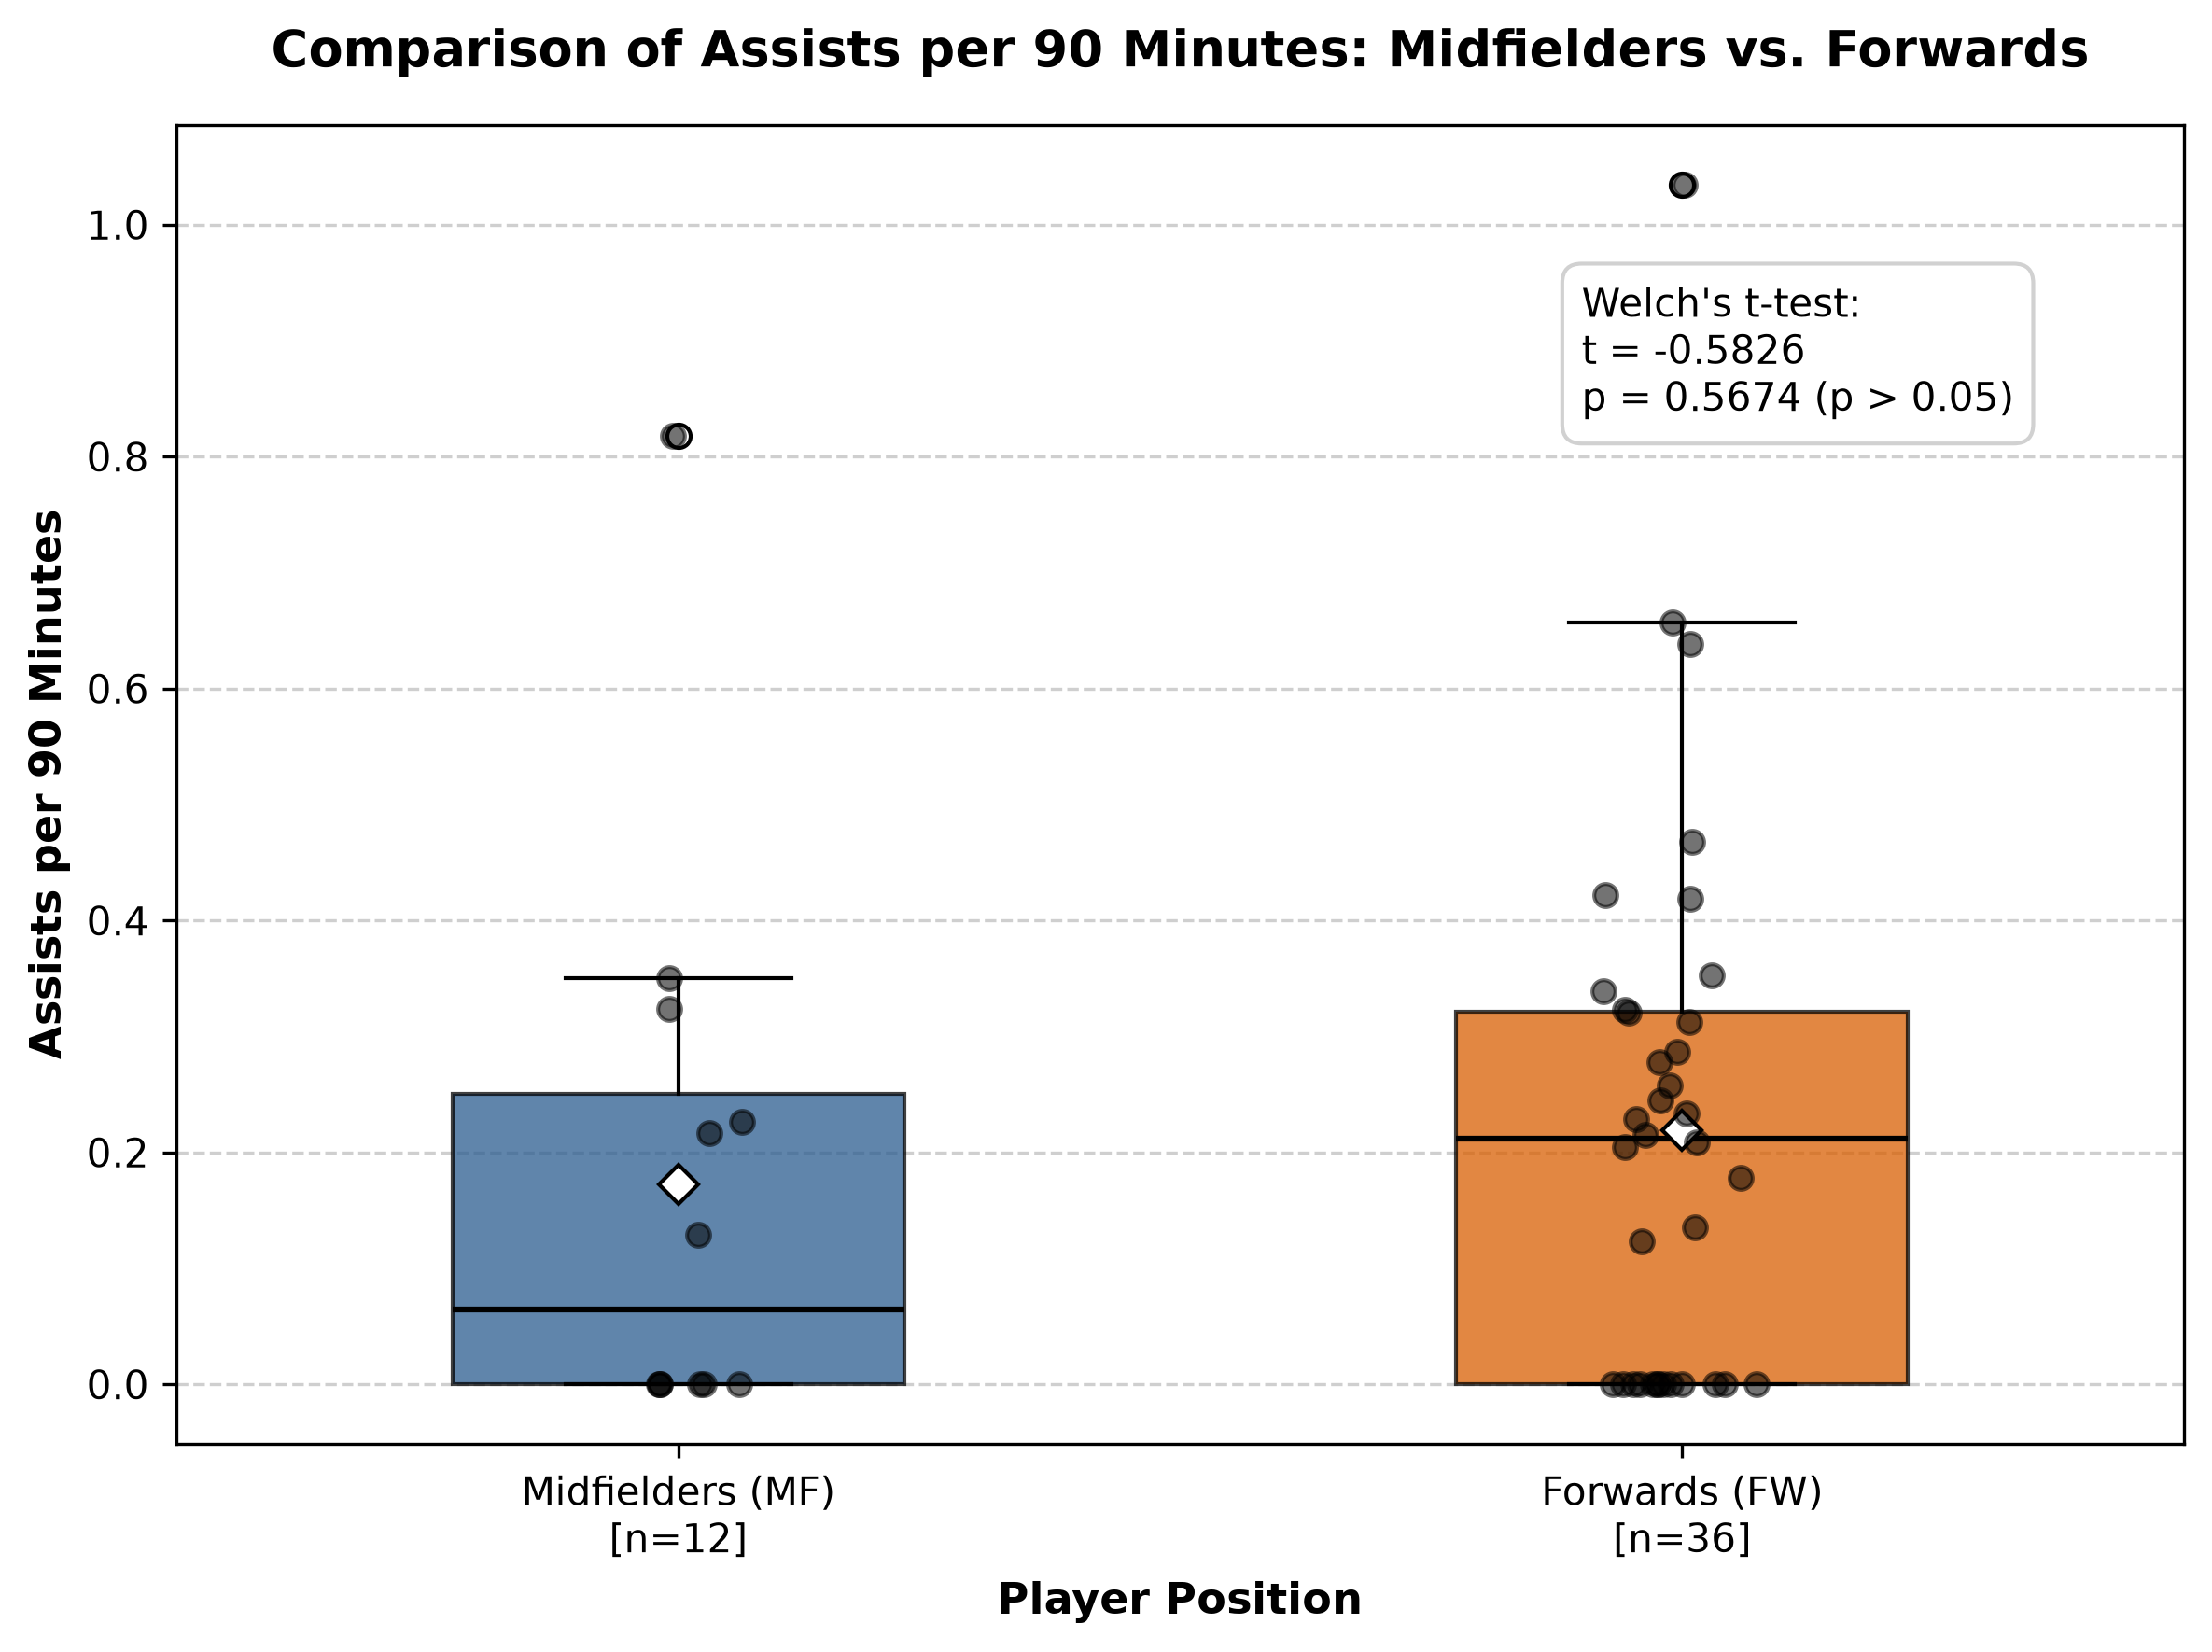

Plot saved successfully to ../data/assists_per_90_ttest.png


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data arrays
mf_vals = df_valid[df_valid['Position'] == 'MF']['Assists_per_90'].values
fw_vals = df_valid[df_valid['Position'] == 'FW']['Assists_per_90'].values

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# 1. Native Boxplot
bp = ax.boxplot(
    [mf_vals, fw_vals],
    positions=[1, 2],
    widths=0.45,
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=7),
    medianprops=dict(color='black', linewidth=1.5)
)

# Colors: MF (Steel Blue), FW (Dark Orange)
colors = ['#2b5c8f', '#d95f02']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# 2. Native Jittered Scatter Overlay
np.random.seed(42)
x_mf = np.random.normal(1, 0.04, size=len(mf_vals))
x_fw = np.random.normal(2, 0.04, size=len(fw_vals))

ax.scatter(x_mf, mf_vals, color='black', alpha=0.55, s=35, zorder=3)
ax.scatter(x_fw, fw_vals, color='black', alpha=0.55, s=35, zorder=3)

# 3. Styling & Labels
ax.set_title("Comparison of Assists per 90 Minutes: Midfielders vs. Forwards", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Player Position", fontsize=11, fontweight='bold')
ax.set_ylabel("Assists per 90 Minutes", fontsize=11, fontweight='bold')
ax.set_xticks([1, 2])
ax.set_xticklabels([f'Midfielders (MF)\n[n={len(mf_vals)}]', f'Forwards (FW)\n[n={len(fw_vals)}]'], fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Statistical annotation
stat_text = "Welch's t-test:\nt = -0.5826\np = 0.5674 (p > 0.05)"
ax.text(
    0.70, 0.88, stat_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.9)
)

plt.tight_layout()
fig_path = "../data/assists_per_90_ttest.png"
plt.savefig(fig_path)
plt.show()
print(f"Plot saved successfully to {fig_path}")